In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

## Parte 1: White Patch

### Imagenes que vamos a procesar

In [2]:
def list_files(directory):
    return sorted([file for file in Path(directory).iterdir() if file.is_file()])

# Imagenes que vamos a procesar
files = list_files("../Material_TPs/TP1/white_patch")
print(f"Numero de Imagenes: {len(files)}")

Numero de Imagenes: 8


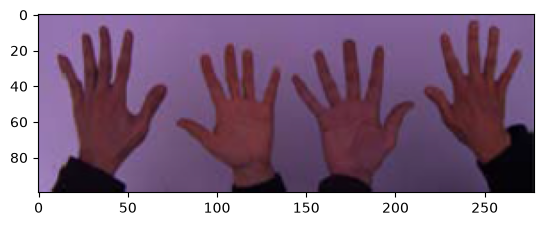

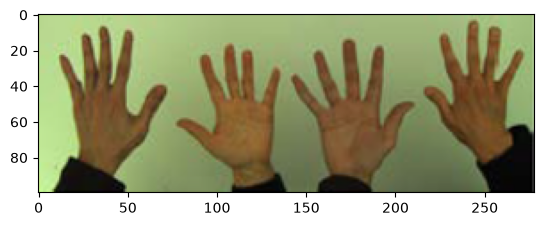

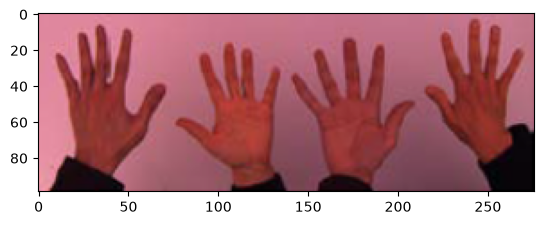

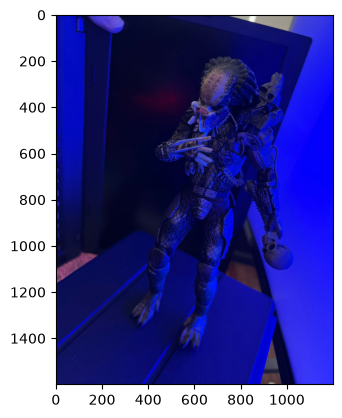

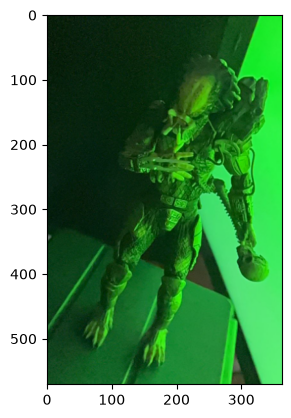

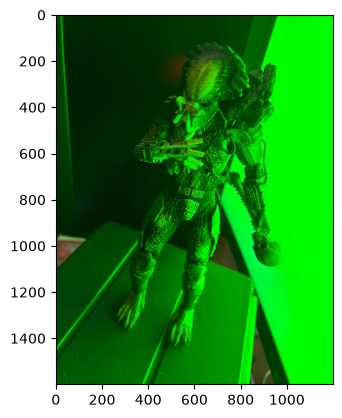

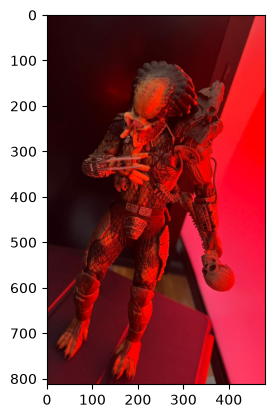

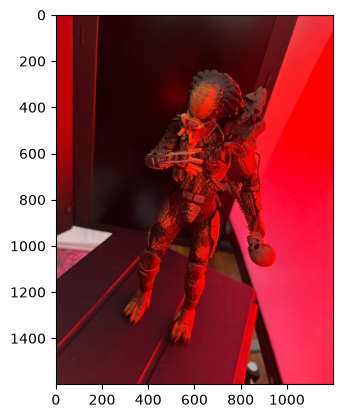

In [3]:
for file in files:
    img = cv.imread(file)
    imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.imshow(imgRGB)
    plt.show()

### Algoritmo

In [4]:
def white_patch(img):
    # Convertir a float
    img = img.astype(np.float32)
    
    # Separar canales
    b, g, r = cv.split(img)
    
    # Encontrar máximos
    r_max, g_max, b_max = np.max(r), np.max(g), np.max(b)
    
    # Normalizar cada canal
    r = r * (255.0 / r_max)
    g = g * (255.0 / g_max)
    b = b * (255.0 / b_max)
    
    # Recombinar y limitar valores
    result = cv.merge([b, g, r])
    result = np.clip(result, 0, 255).astype(np.uint8)
    
    return result

### Imagenes procesadas

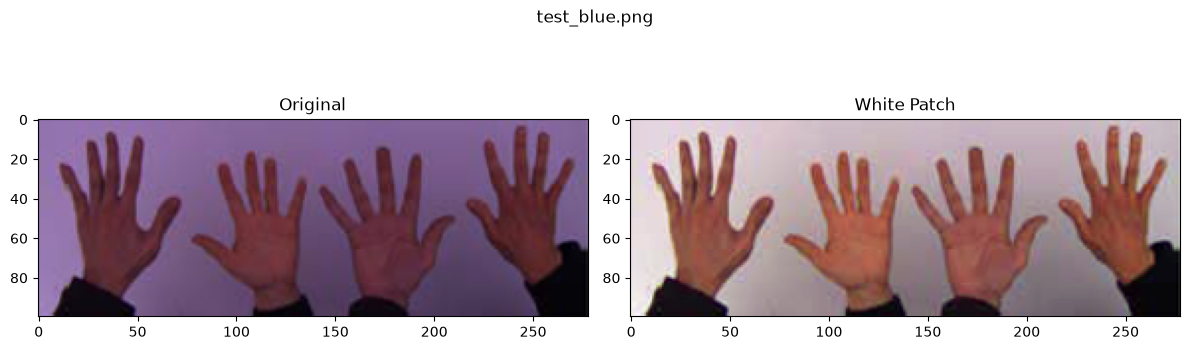

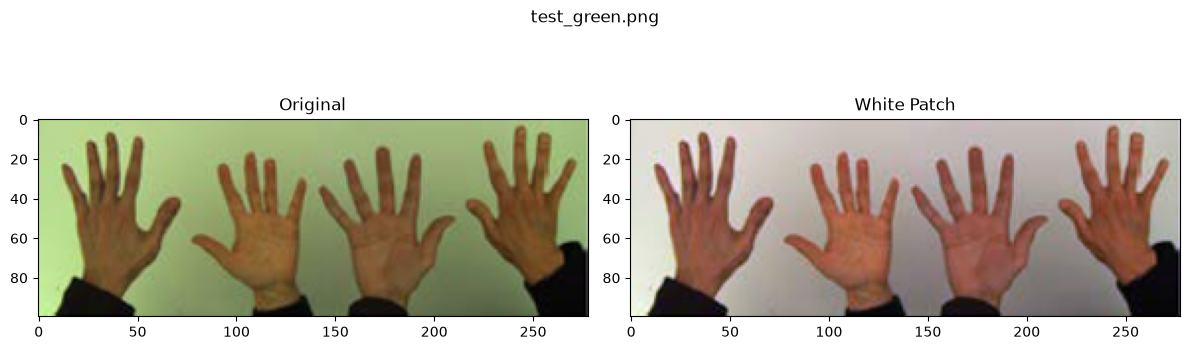

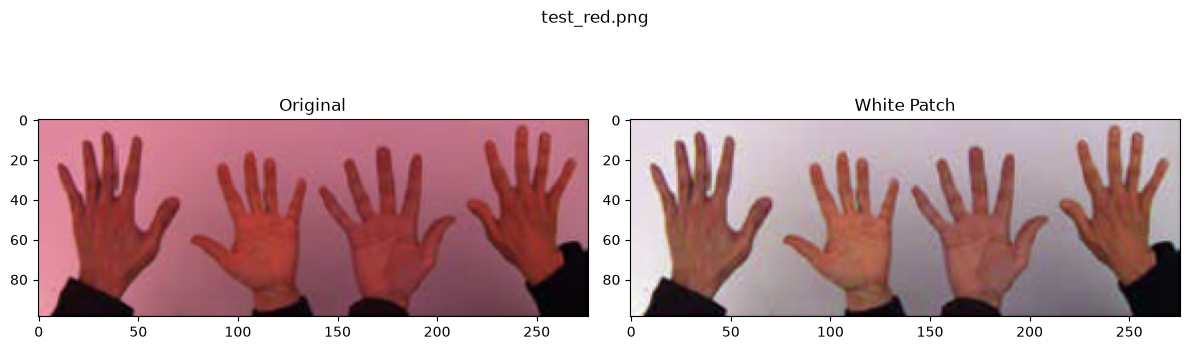

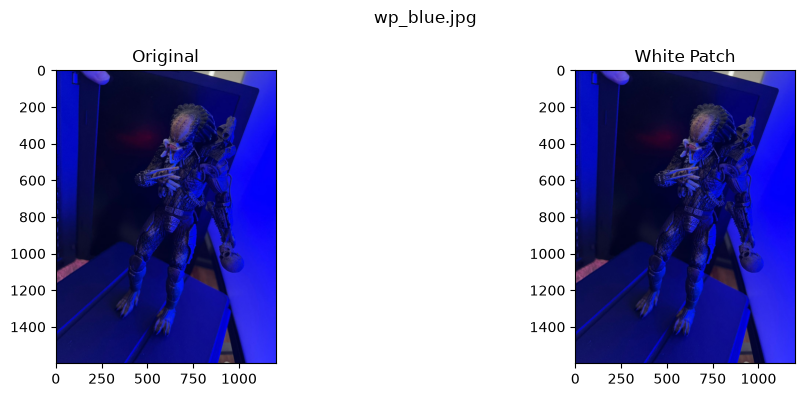

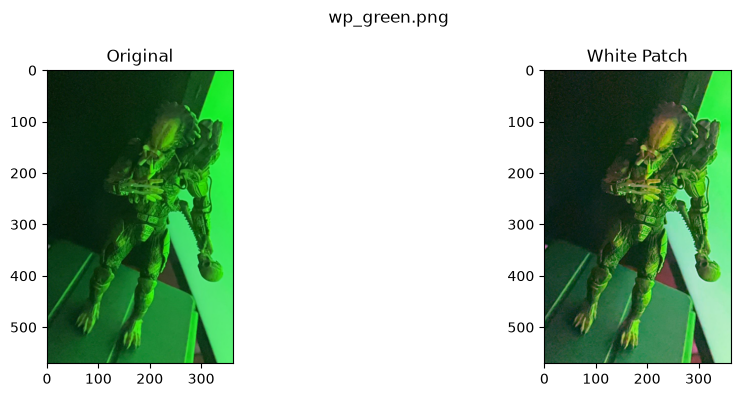

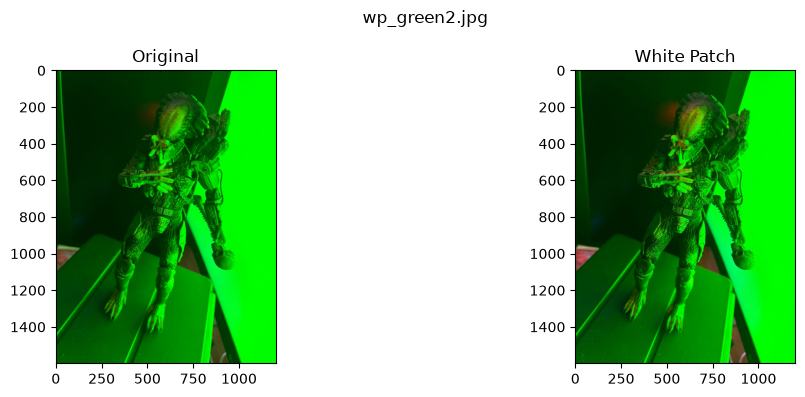

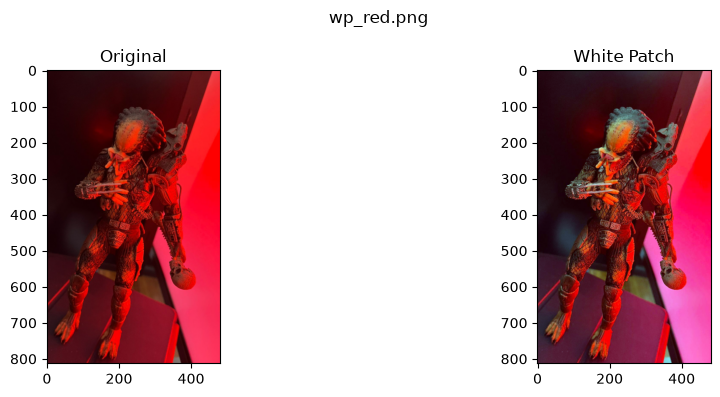

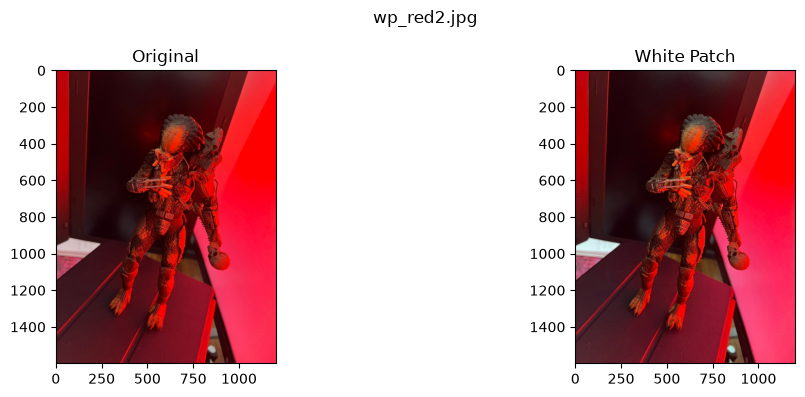

In [5]:
for file in files:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    img = cv.imread(file)
    imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    processed = white_patch(imgRGB)

    axs[0].imshow(imgRGB)
    axs[0].set_title("Original")
    
    axs[1].imshow(processed)
    axs[1].set_title("White Patch")

    fig.suptitle(file.name)

    plt.tight_layout()
    plt.show()

Se observa que *white patch* funciona bien cuando la iluminación de color es tenue: logra neutralizarla y devolver un fondo blanco más natural, como en las imágenes de las manos. Sin embargo, cuando la iluminación es muy intensa (como en el resto de las imagenes), el método apenas produce cambios. Esto puede considerarse una falla, ya que cuando la iluminación de color es demasiado intensa el algoritmo no logra compensarla. Lo que se observa es que el resultado apenas muestra cambios o se vuelve casi imperceptible, lo que indica que el método funciona mejor con iluminaciones suaves pero pierde eficacia frente a luces de colores mas intensos.

## Parte 2: Histogramas

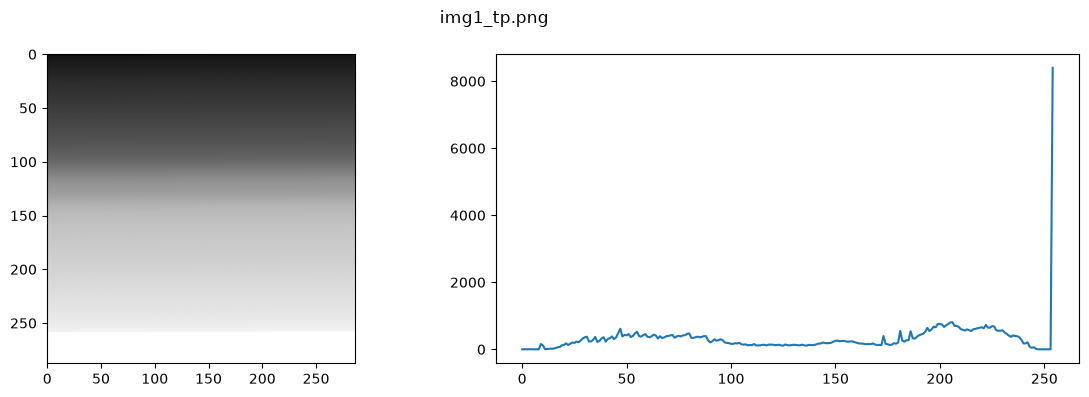

In [6]:
BINS = 255

img1 = cv.imread("../Material_TPs/TP1/img1_tp.png", cv.IMREAD_GRAYSCALE)
hist1, _ = np.histogram(img1, BINS, [0, 256])

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

fig.suptitle("img1_tp.png")

axs[0].imshow(img1, cmap="gray")
axs[1].plot(hist1)

plt.tight_layout()
plt.show()

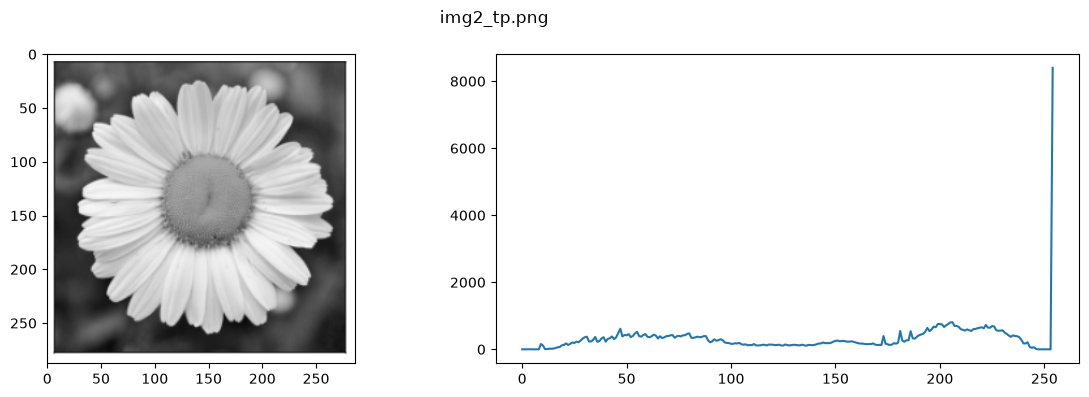

In [7]:
img2 = cv.imread("../Material_TPs/TP1/img2_tp.png", cv.IMREAD_GRAYSCALE)
hist2, _ = np.histogram(img2, BINS, [0, 256])

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

fig.suptitle("img2_tp.png")

axs[0].imshow(img2, cmap="gray")
axs[1].plot(hist2)

plt.tight_layout()
plt.show()

Observamos que los histogramas son identicos:

In [8]:
all(hist1 == hist2)

True

Lo que se observa es que, aunque las imágenes sean visualmente muy distintas (una flor y una escala de grises), sus histogramas resultan idénticos porque la distribución de intensidades de píxeles es la misma. Esto muestra que el histograma captura únicamente la frecuencia de valores de gris y no la estructura espacial de la imagen. 

Por eso, si bien los histogramas pueden ser útiles como features en ciertos casos (por ejemplo, para distinguir imágenes con diferentes contrastes o iluminaciones), no son suficientes para tareas de clasificación o detección más complejas, ya que pierden información sobre la forma y el contenido de la imagen.